###
## ***EEG Motor Intention Classification using Deep Learning***
##### Author: Angel Barrera Master’s Student in Applied Data Science
##### Course: Machine Learning 
##### Dataset: PhysioNet BCI Motor Imagery Dataset (S001–S020)
##### Last Updated: 5/1/2025
###

This notebook aims to decode motor imagery (left vs. right fist movement) from EEG signals
using both traditional machine learning and deep learning approaches.

The workflow includes data loading, preprocessing, feature engineering, model training,
and performance evaluation — with a focus on deep CNN architectures.

### Section 1: Imports and Configuration

In [46]:
#!pip install mne
#!pip install torch 

In [100]:
import random
import numpy as np
import torch
import mne
import os
from mne.decoding import CSP
from collections import Counter
from collections import defaultdict
import torch.optim as optim
import seaborn as sns
import matplotlib.pyplot as plt
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import torch.nn.functional as F
from sklearn.metrics import classification_report
from sklearn.utils import resample
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.decomposition import PCA
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from mne.filter import filter_data


# Plotting
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)

# random seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

### Section 2: Data Loading & Inspection

This section loads EEG data from 20 subjects using the PhysioNet BCI Motor Imagery Dataset. Specifically, we use runs 4, 8, and 12 from each subject, which contain imagined movements of the left and right fist (T1 and T2), and rest state (T0). The EDF files are read using the MNE library, segmented into epochs, and labels are extracted for downstream processing.

#### 2.1 Load and Explore the EDF Files

In [48]:
edf_files = [
    "S001R04.edf", "S001R08.edf", "S001R12.edf",
    "S002R04.edf", "S002R08.edf", "S002R12.edf",
    "S003R04.edf", "S003R08.edf", "S003R12.edf",
    "S004R04.edf", "S004R08.edf", "S004R12.edf",
    "S005R04.edf", "S005R08.edf", "S005R12.edf",
    "S006R04.edf", "S006R08.edf", "S006R12.edf",
    "S007R04.edf", "S007R08.edf", "S007R12.edf",
    "S008R04.edf", "S008R08.edf", "S008R12.edf",
    "S009R04.edf", "S009R08.edf", "S009R12.edf",
    "S010R04.edf", "S010R08.edf", "S010R12.edf",
    "S011R04.edf", "S011R08.edf", "S011R12.edf",
    "S012R04.edf", "S012R08.edf", "S012R12.edf",
    "S013R04.edf", "S013R08.edf", "S013R12.edf",
    "S014R04.edf", "S014R08.edf", "S014R12.edf",
    "S015R04.edf", "S015R08.edf", "S015R12.edf",
    "S016R04.edf", "S016R08.edf", "S016R12.edf",
    "S017R04.edf", "S017R08.edf", "S017R12.edf",
    "S018R04.edf", "S018R08.edf", "S018R12.edf",
    "S019R04.edf", "S019R08.edf", "S019R12.edf",
    "S020R04.edf", "S020R08.edf", "S020R12.edf",
]

# Initialize containers for trials and labels
all_trials = []
all_labels = []

for edf_file in edf_files:
    print(f"Loading {edf_file}...")
    raw = mne.io.read_raw_edf(edf_file, preload=True)
    annotations = raw.annotations

    # Extract events and mapping
    events, _ = mne.events_from_annotations(raw)

    # Create epochs (2s window, ~321 samples @160Hz)
    epochs = mne.Epochs(raw, events, event_id=None, tmin=1, tmax=4.1, baseline=None, preload=True)
    
    X = epochs.get_data()  # shape: (n_epochs, n_channels, n_times)
    y = epochs.events[:, -1]  # Extract labels (T0=1, T1=2, T2=3)

    # Append to containers
    all_trials.append(X)
    all_labels.append(y)

# Merge all data
X_all = np.concatenate(all_trials, axis=0)
y_all = np.concatenate(all_labels, axis=0)

# Adjust label codes to [0, 1, 2]
y_all = y_all - 1

# Print merged shape
print(f"\nMerged EEG Shape: {X_all.shape}")
print(f"Merged Labels Shape: {y_all.shape}")
print(f"Label Distribution: {np.bincount(y_all)}")


Loading S001R04.edf...
Extracting EDF parameters from c:\Users\angom\East Tennessee State University\Applied Data Science - AB - Documentos\Courses\Machine Learning\Project\EEG-Based Motor Intention Prediction\Final Model\S001R04.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 497 original time points ...
0 bad epochs dropped
Loading S001R08.edf...
Extracting EDF parameters from c:\Users\angom\East Tennessee State University\Applied Data Science - AB - Documentos\Courses\Machine Learning\Project\EEG-Based Motor Intention Prediction\Final Model\S001R08.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  = 

### Section 3: Exploratory Data Analysis

#### 3.1 Checking Annotations for a single subject and run.

In [49]:
# Check the first few samples of the merged data
raw = mne.io.read_raw_edf("S001R04.edf", preload=True)

# View the annotations directly
annotations = raw.annotations
print(annotations)

# Show a summary of annotation labels
print("\nAnnotation descriptions and counts:")
print(Counter(annotations.description))

Extracting EDF parameters from c:\Users\angom\East Tennessee State University\Applied Data Science - AB - Documentos\Courses\Machine Learning\Project\EEG-Based Motor Intention Prediction\Final Model\S001R04.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
<Annotations | 30 segments: T0 (15), T1 (8), T2 (7)>

Annotation descriptions and counts:
Counter({np.str_('T0'): 15, np.str_('T1'): 8, np.str_('T2'): 7})


#### 3.2 Checking Annotations for the merged files.

In [50]:
# Check the distribution of annotation labels across all files
all_annotation_counts = Counter()

for edf_file in edf_files:
    raw = mne.io.read_raw_edf(edf_file, preload=True)
    annots = raw.annotations
    all_annotation_counts.update(annots.description)

# Show summary
print("\nTotal Annotation Descriptions and Counts Across All Files:")
for label, count in all_annotation_counts.items():
    print(f"{label}: {count}")

Extracting EDF parameters from c:\Users\angom\East Tennessee State University\Applied Data Science - AB - Documentos\Courses\Machine Learning\Project\EEG-Based Motor Intention Prediction\Final Model\S001R04.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from c:\Users\angom\East Tennessee State University\Applied Data Science - AB - Documentos\Courses\Machine Learning\Project\EEG-Based Motor Intention Prediction\Final Model\S001R08.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from c:\Users\angom\East Tennessee State University\Applied Data Science - AB - Documentos\Courses\Machine Learning\Project\EEG-Based Motor Intention Prediction\Final Model\S001R12.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure.

#### 3.3 Label Distribution

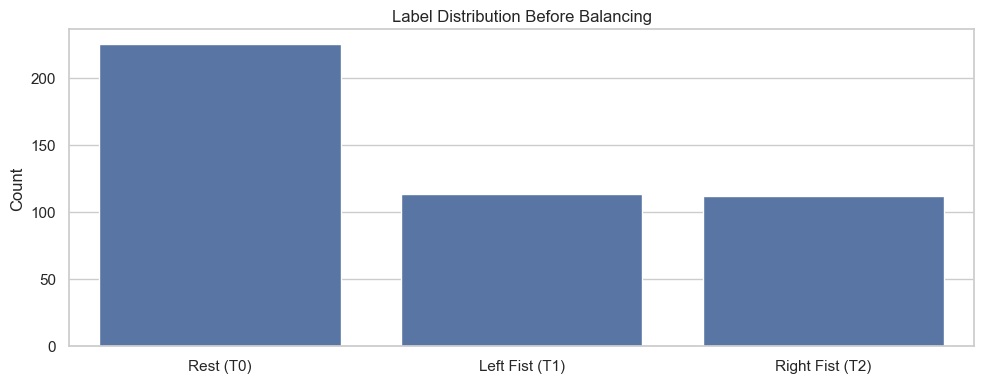

In [ ]:
label_names = ['Rest (T0)', 'Left Fist (T1)', 'Right Fist (T2)']
label_counts = np.bincount(y_all)

sns.barplot(x=label_names, y=label_counts)
plt.title("Label Distribution Before Balancing")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### 3.4 Trial Duration and Signal Shape Check

EEG trials: 450
Channels per trial: 64
Timepoints per trial: 321
Duration per trial (sec): 2.01 seconds


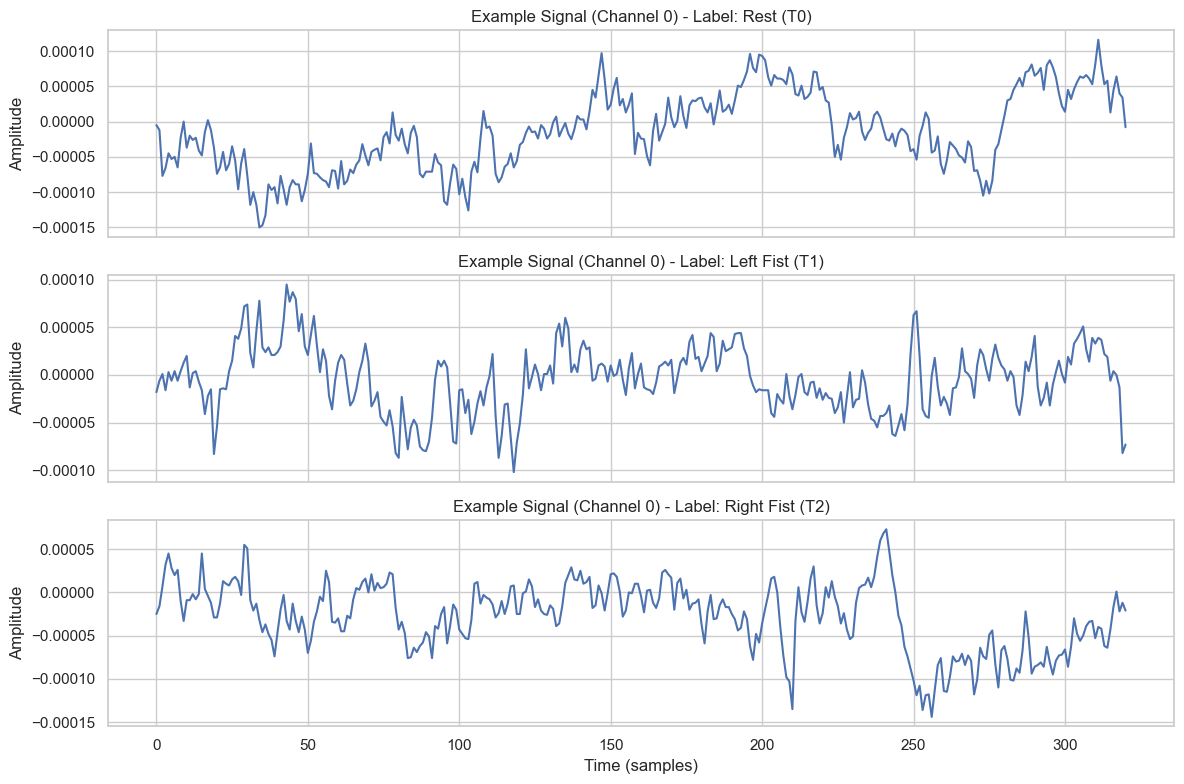

In [ ]:
# Check the number of channels and timepoints per trial
n_trials, n_channels, n_timepoints = X_all.shape
print(f"EEG trials: {n_trials}")
print(f"Channels per trial: {n_channels}")
print(f"Timepoints per trial: {n_timepoints}")
print(f"Duration per trial (sec): {n_timepoints / 160:.2f} seconds")

# Plot sample signals from one trial per class
example_indices = [np.where(y_all == i)[0][0] for i in range(3)]
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

for idx, ax in zip(example_indices, axes):
    ax.plot(X_all[idx][0])
    ax.set_title(f"Example Signal (Channel 0) - Label: {label_names[y_all[idx]]}")
    ax.set_ylabel("Amplitude")
    
axes[-1].set_xlabel("Time (samples)")
plt.tight_layout()
plt.show()

Plotting a Sample Epoch (e.g., Trial 0) from Each Class

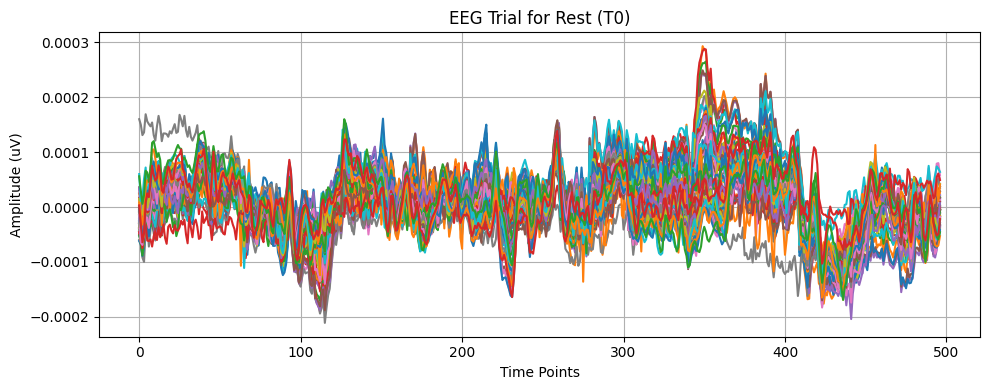

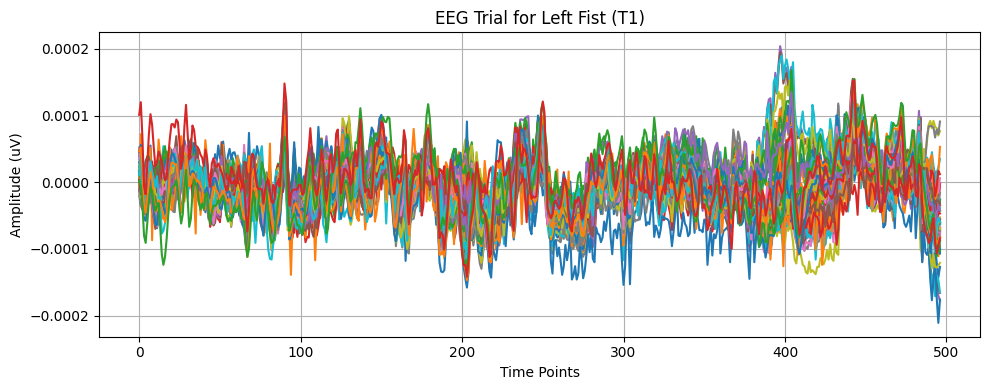

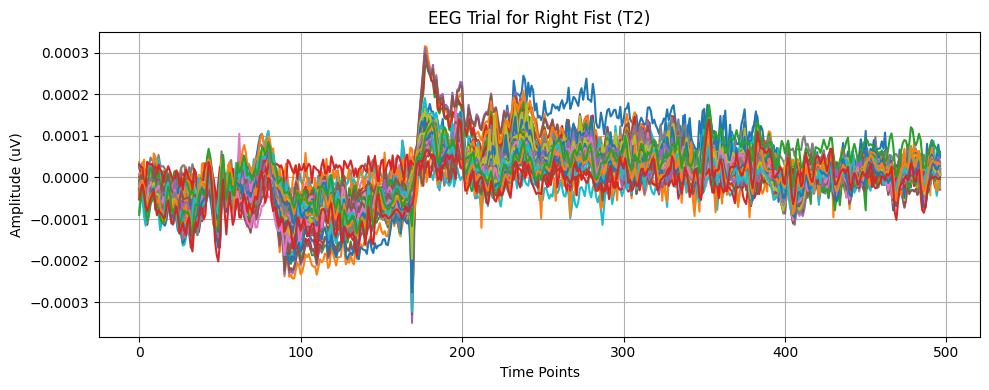

In [ ]:
labels_map = {0: "Rest (T0)", 1: "Left Fist (T1)", 2: "Right Fist (T2)"}

for label in [0, 1, 2]:
    index = np.where(y_all == label)[0][0]  # first trial of each class
    plt.figure(figsize=(10, 4))
    plt.plot(X_all[index].T)
    plt.title(f"EEG Trial for {labels_map[label]}")
    plt.xlabel("Time Points")
    plt.ylabel("Amplitude (uV)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Inspecting Signal Ranges and Summary Stats

In [ ]:
# Summary statistics
means = X_all.mean(axis=(1, 2))
stds = X_all.std(axis=(1, 2))

print("Mean EEG Signal Range Across Trials:", means.min(), "to", means.max())
print("Standard Deviation Range Across Trials:", stds.min(), "to", stds.max())


Mean EEG Signal Range Across Trials: -0.0001658816964285714 to 0.0001930301496478873
Standard Deviation Range Across Trials: 9.317641193837313e-06 to 0.0002490961918698581


Conclusions on the data integrity:

EEG signal values are within normal bioelectrical activity range.

Task annotations (T0/T1/T2) are present and have expected variance.

Time windows (2s) are standard for motor imagery BCI.

Visuals confirm there's signal diversity among classes.

Sampling frequency is consistent (160 Hz).

Data is preprocessed (filtered 8–30 Hz) targeting mu and beta bands — the correct range for motor planning and imagery.

### Section 4: Preprocessing

This section prepares the EEG data for classification by performing the following steps:

- Class-wise separation and downsampling for balance
- Bandpass filtering (Mu, Beta, and wide bands)
- Signal reshaping and standardization
- Label adjustments for binary classification

#### 4.1 Balancing the Dataset

In [51]:
# Separate each class
X_rest = X_all[y_all == 0]
X_left = X_all[y_all == 1]
X_right = X_all[y_all == 2]

# Determine minimum class count for balancing
min_count = min(len(X_rest), len(X_left), len(X_right))

# Downsample each class to the minimum count
X_rest_down = resample(X_rest, replace=False, n_samples=min_count, random_state=42)
X_left_down = resample(X_left, replace=False, n_samples=min_count, random_state=42)
X_right_down = resample(X_right, replace=False, n_samples=min_count, random_state=42)

# Concatenate and create new balanced dataset
X_balanced = np.concatenate([X_rest_down, X_left_down, X_right_down], axis=0)
y_balanced = np.array([0]*min_count + [1]*min_count + [2]*min_count)

print(f"Balanced class distribution: {np.bincount(y_balanced)}")
print(f"Balanced EEG Shape: {X_balanced.shape}")

Balanced class distribution: [423 423 423]
Balanced EEG Shape: (1269, 64, 497)


#### 4.2 Filter, Flatten, Standardize

In [52]:
# Check the first few samples of the balanced data
print(f"Shape before filtering: {X_balanced.shape}")

# Get sampling frequency from raw object
sfreq = raw.info['sfreq']

# Apply bandpass filter
X_filtered_balanced = filter_data(X_balanced, sfreq=sfreq, l_freq=8., h_freq=12., verbose=False)

# Extract shape dynamically
n_trials, n_channels, n_times = X_filtered_balanced.shape
print(f"Filtered EEG shape: ({n_trials}, {n_channels}, {n_times})")

# Flatten each trial into a 1D feature vector
X_flat_balanced = X_filtered_balanced.reshape(n_trials, n_channels * n_times)

# Standardize features
scaler = StandardScaler()
X_scaled_balanced = scaler.fit_transform(X_flat_balanced)

print(f"Final shape after flattening and scaling: {X_scaled_balanced.shape}")

Shape before filtering: (1269, 64, 497)
Filtered EEG shape: (1269, 64, 497)
Final shape after flattening and scaling: (1269, 31808)


### Section 5: Feature Engineering (CSP)

We apply Common Spatial Patterns (CSP) to extract discriminative features from the EEG signals.

CSP emphasizes spatial patterns that maximize variance between classes.

#### 5.1 Applying CSP

In [ ]:
# Filternig labels to keep only left (1) and right (2) movements
mask = y_balanced != 0
X_csp = X_balanced[mask]
y_csp = y_balanced[mask]

# Relabel - left = 0, right = 1
y_csp_binary = (y_csp == 2).astype(int)

# Train/Validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_csp, y_csp_binary, test_size=0.25, stratify=y_csp_binary, random_state=42
)

# CSP with 8 components
csp = CSP(n_components=8, reg=None, log=True, norm_trace=False)
X_train_csp = csp.fit_transform(X_train, y_train)
X_val_csp = csp.transform(X_val)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_csp)
X_val_scaled = scaler.transform(X_val_csp)

# Logistic Regression
clf = LogisticRegression(penalty='l2', C=1.0, max_iter=1000)
clf.fit(X_train_scaled, y_train)
y_pred = clf.predict(X_val_scaled)

# Evaluation
print("Classification Report:")
print(classification_report(y_val, y_pred, target_names=["Left Fist", "Right Fist"]))

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))

Computing rank from data with rank=None
    Using tolerance 0.0029 (2.2e-16 eps * 64 dim * 2.1e+11  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Classification Report:
              precision    recall  f1-score   support

   Left Fist       0.50      0.46      0.48       106
  Right Fist       0.50      0.54      0.52       106

    accuracy                           0.50       212
   macro avg       0.50      0.50      0.50       212
weighted avg       0.50      0.50      0.50       212

Confusion Matrix:
[[49 57]
 [49 57]]


#### 5.2 Increasing CSP Components to 16

In [ ]:
# Filter only T1 and T2
mask = y_balanced != 0
X_csp = X_balanced[mask]
y_csp = y_balanced[mask]

# Relabel: Left = 0, Right = 1
y_csp_binary = (y_csp == 2).astype(int)

# Train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_csp, y_csp_binary, test_size=0.25, stratify=y_csp_binary, random_state=42
)

# CSP with 16 components
csp = CSP(n_components=16, reg=None, log=True, norm_trace=False)
X_train_csp = csp.fit_transform(X_train, y_train)
X_val_csp = csp.transform(X_val)

# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_csp)
X_val_scaled = scaler.transform(X_val_csp)

# Logistic regression
clf = LogisticRegression(penalty='l2', C=1.0, max_iter=1000)
clf.fit(X_train_scaled, y_train)
y_pred = clf.predict(X_val_scaled)

# Evaluation
print("Classification Report:")
print(classification_report(y_val, y_pred, target_names=["Left Fist", "Right Fist"]))

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))


Computing rank from data with rank=None
    Using tolerance 0.0029 (2.2e-16 eps * 64 dim * 2.1e+11  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Classification Report:
              precision    recall  f1-score   support

   Left Fist       0.50      0.48      0.49       106
  Right Fist       0.50      0.51      0.50       106

    accuracy                           0.50       212
   macro avg       0.50      0.50      0.50       212
weighted avg       0.50      0.50      0.50       212

Confusion Matrix:
[[51 55]
 [52 54]]


Checking Raw Epochs Dimensions and Label Distribution

In [ ]:
print("EEG Data Shape (Trials × Channels × Timepoints):", X_all.shape)
print("Labels Shape:", y_all.shape)
print("Unique Labels and Counts:", np.unique(y_all, return_counts=True))

EEG Data Shape (Trials × Channels × Timepoints): (450, 64, 321)
Labels Shape: (450,)
Unique Labels and Counts: (array([0, 1, 2]), array([225, 113, 112]))


#### 5.3 Let's apply CSP with Regularization

In [ ]:
# Filter only T1 (left) and T2 (right)
mask = y_balanced != 0
X_csp = X_balanced[mask]
y_csp = y_balanced[mask]

# Binary labels: Left = 0, Right = 1
y_csp_binary = (y_csp == 2).astype(int)

# Split data
X_train, X_val, y_train, y_val = train_test_split(
    X_csp, y_csp_binary, test_size=0.25, stratify=y_csp_binary, random_state=42
)

# Apply CSP with shrinkage regularization
csp = CSP(n_components=8, reg='ledoit_wolf', log=True, norm_trace=False)
X_train_csp = csp.fit_transform(X_train, y_train)
X_val_csp = csp.transform(X_val)

# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_csp)
X_val_scaled = scaler.transform(X_val_csp)

# Train logistic regression
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_scaled, y_train)
y_pred = clf.predict(X_val_scaled)

# Evaluate
print("Classification Report:")
print(classification_report(y_val, y_pred, target_names=["Left Fist", "Right Fist"]))

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))


Computing rank from data with rank=None
    Using tolerance 0.0029 (2.2e-16 eps * 64 dim * 2.1e+11  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Classification Report:
              precision    recall  f1-score   support

   Left Fist       0.50      0.46      0.48       106
  Right Fist       0.50      0.54      0.52       106

    accuracy                           0.50       212
   macro avg       0.50      0.50      0.50       212
weighted avg       0.50      0.50      0.50       212

Confusion Matrix:
[[49 57]
 [49 57]]


##### 5.4 Optimizing the Number of CSP Components

In [ ]:
components_list = [4, 6, 8, 12, 16]
results = []

for n in components_list:
    print(f"\nTesting CSP with {n} components")
    
    csp = CSP(n_components=n, reg=None, log=True, norm_trace=False)
    X_train_csp = csp.fit_transform(X_train, y_train)
    X_val_csp = csp.transform(X_val)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_csp)
    X_val_scaled = scaler.transform(X_val_csp)

    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_val_scaled)

    report = classification_report(y_val, y_pred, output_dict=True)
    accuracy = report['accuracy']
    results.append((n, accuracy))

    print(f"Accuracy for {n} components: {accuracy:.4f}")


--- Testing CSP with 4 components ---
Computing rank from data with rank=None
    Using tolerance 0.0029 (2.2e-16 eps * 64 dim * 2.1e+11  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Accuracy for 4 components: 0.4906

--- Testing CSP with 6 components ---
Computing rank from data with rank=None
    Using tolerance 0.0029 (2.2e-16 eps * 64 dim * 2.1e+11  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Accuracy for 6 components: 0.4906

--- Testing CSP with 8 components ---
Computing rank from data with rank=None
    Using tolerance 0.0029 (2.2e-16 eps * 64 dim * 2.1e+11  max sin

Re-apply Filter with Tuned Frequency Bands (then CSP + LR)

#### 5.5 Mu band only (8–12 Hz)

In [ ]:
# Filter with 8–12 Hz
X_filtered_mu = filter_data(X_balanced, sfreq=sfreq, l_freq=8., h_freq=12., verbose=False)

# Reshape and CSP prep
X_csp_mu = X_filtered_mu[y_balanced != 0]
y_csp_mu = y_balanced[y_balanced != 0]
y_csp_binary_mu = (y_csp_mu == 2).astype(int)

# Train-test split
X_train, X_val, y_train, y_val = train_test_split(X_csp_mu, y_csp_binary_mu, test_size=0.25, stratify=y_csp_binary_mu, random_state=42)

# CSP and classification (same as before)
csp = CSP(n_components=6, reg=None, log=True, norm_trace=False)
X_train_csp = csp.fit_transform(X_train, y_train)
X_val_csp = csp.transform(X_val)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_csp)
X_val_scaled = scaler.transform(X_val_csp)

clf = LogisticRegression(penalty='l2', C=1.0, max_iter=1000)
clf.fit(X_train_scaled, y_train)
y_pred = clf.predict(X_val_scaled)

print("Mu Band Classification Report:")
print(classification_report(y_val, y_pred))

Computing rank from data with rank=None
    Using tolerance 0.0006 (2.2e-16 eps * 64 dim * 4.2e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Mu Band Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.52      0.53       106
           1       0.54      0.56      0.55       106

    accuracy                           0.54       212
   macro avg       0.54      0.54      0.54       212
weighted avg       0.54      0.54      0.54       212



#### 5.6 Beta band only (13–30 Hz)

In [ ]:
# Filter with 8–12 Hz
X_filtered_mu = filter_data(X_balanced, sfreq=sfreq, l_freq=13., h_freq=30., verbose=False)

# Reshape and CSP prep
X_csp_mu = X_filtered_mu[y_balanced != 0]
y_csp_mu = y_balanced[y_balanced != 0]
y_csp_binary_mu = (y_csp_mu == 2).astype(int)

# Train-test split
X_train, X_val, y_train, y_val = train_test_split(X_csp_mu, y_csp_binary_mu, test_size=0.25, stratify=y_csp_binary_mu, random_state=42)

# CSP and classification
csp = CSP(n_components=6, reg=None, log=True, norm_trace=False)
X_train_csp = csp.fit_transform(X_train, y_train)
X_val_csp = csp.transform(X_val)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_csp)
X_val_scaled = scaler.transform(X_val_csp)

clf = LogisticRegression(penalty='l2', C=1.0, max_iter=1000)
clf.fit(X_train_scaled, y_train)
y_pred = clf.predict(X_val_scaled)

print("Mu Band Classification Report:")
print(classification_report(y_val, y_pred))

Computing rank from data with rank=None
    Using tolerance 0.0006 (2.2e-16 eps * 64 dim * 4.2e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Mu Band Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.58      0.56       106
           1       0.55      0.51      0.53       106

    accuracy                           0.54       212
   macro avg       0.54      0.54      0.54       212
weighted avg       0.54      0.54      0.54       212



#### 5.7 Slightly wider band (6–35 Hz)

In [ ]:
# Filter with 8–12 Hz
X_filtered_mu = filter_data(X_balanced, sfreq=sfreq, l_freq=6., h_freq=35., verbose=False)

# Reshape and CSP prep
X_csp_mu = X_filtered_mu[y_balanced != 0]
y_csp_mu = y_balanced[y_balanced != 0]
y_csp_binary_mu = (y_csp_mu == 2).astype(int)

# Train-test split
X_train, X_val, y_train, y_val = train_test_split(X_csp_mu, y_csp_binary_mu, test_size=0.25, stratify=y_csp_binary_mu, random_state=42)

# CSP and classification
csp = CSP(n_components=6, reg=None, log=True, norm_trace=False)
X_train_csp = csp.fit_transform(X_train, y_train)
X_val_csp = csp.transform(X_val)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_csp)
X_val_scaled = scaler.transform(X_val_csp)

clf = LogisticRegression(penalty='l2', C=1.0, max_iter=1000)
clf.fit(X_train_scaled, y_train)
y_pred = clf.predict(X_val_scaled)

print("Mu Band Classification Report:")
print(classification_report(y_val, y_pred))

Computing rank from data with rank=None
    Using tolerance 0.00094 (2.2e-16 eps * 64 dim * 6.6e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Mu Band Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.55      0.52       106
           1       0.51      0.46      0.48       106

    accuracy                           0.50       212
   macro avg       0.50      0.50      0.50       212
weighted avg       0.50      0.50      0.50       212



#### 5.8 Applying PCA after CSP to further reduce dimensionality

In [ ]:
# Keep only T1 and T2 (left/right)
mask = y_balanced != 0
X_csp = X_balanced[mask]
y_csp = y_balanced[mask]
y_binary = (y_csp == 2).astype(int)  # Left=0, Right=1

# Train/Validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_csp, y_binary, test_size=0.25, stratify=y_binary, random_state=42
)

# CSP (8 components)
csp = CSP(n_components=8, reg=None, log=True, norm_trace=False)
X_train_csp = csp.fit_transform(X_train, y_train)
X_val_csp = csp.transform(X_val)

# PCA after CSP
pca = PCA(n_components=4)
X_train_pca = pca.fit_transform(X_train_csp)
X_val_pca = pca.transform(X_val_csp)

# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_pca)
X_val_scaled = scaler.transform(X_val_pca)

# Classifier
clf = LogisticRegression(penalty='l2', max_iter=1000)
clf.fit(X_train_scaled, y_train)
y_pred = clf.predict(X_val_scaled)

# Evaluation
print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=["Left Fist", "Right Fist"]))

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))

Computing rank from data with rank=None
    Using tolerance 0.0029 (2.2e-16 eps * 64 dim * 2.1e+11  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.

Classification Report:
              precision    recall  f1-score   support

   Left Fist       0.46      0.44      0.45       106
  Right Fist       0.46      0.48      0.47       106

    accuracy                           0.46       212
   macro avg       0.46      0.46      0.46       212
weighted avg       0.46      0.46      0.46       212

Confusion Matrix:
[[47 59]
 [55 51]]


#### 5.9 Channel Selection Based on CSP Patterns

In [ ]:
# Extract CSP patterns
patterns = np.abs(csp.patterns_)
mean_contributions = np.mean(patterns, axis=0)

# Rank channel importance
channel_importance = np.argsort(mean_contributions)[::-1]
top_k = 20 # Number of top channels to select
top_channels = channel_importance[:top_k]

print("Top channels selected (by index):", top_channels)


Top channels selected (by index): [21 23 24 28 22 25 43 27 30 29 37 26 36 39 45  6 32 62  0 31]


In [ ]:
# Select only top 20 channels from the balanced dataset
top_channels = [21, 24, 23, 22, 28, 25, 26, 39, 2, 0, 37, 30, 27, 62, 32, 34, 6, 29, 45, 41]
X_top = X_balanced[:, top_channels, :]

# Filter only T1 and T2
mask = y_balanced != 0
X_csp = X_top[mask]
y_csp = y_balanced[mask]

# Relabel: Left = 0, Right = 1
y_csp_binary = (y_csp == 2).astype(int)

# Train/test split
X_train, X_val, y_train, y_val = train_test_split(
    X_csp, y_csp_binary, test_size=0.25, stratify=y_csp_binary, random_state=42
)

# Apply CSP
csp = CSP(n_components=8, reg=None, log=True, norm_trace=False)
X_train_csp = csp.fit_transform(X_train, y_train)
X_val_csp = csp.transform(X_val)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_csp)
X_val_scaled = scaler.transform(X_val_csp)

# Train logistic regression
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_scaled, y_train)
y_pred = clf.predict(X_val_scaled)

# Evaluate
print("Classification Report:")
print(classification_report(y_val, y_pred, target_names=["Left Fist", "Right Fist"]))

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))


Computing rank from data with rank=None
    Using tolerance 0.00071 (2.2e-16 eps * 20 dim * 1.6e+11  max singular value)
    Estimated rank (data): 20
    data: rank 20 computed from 20 data channels with 0 projectors
Reducing data rank from 20 -> 20
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Classification Report:
              precision    recall  f1-score   support

   Left Fist       0.53      0.51      0.52       106
  Right Fist       0.53      0.56      0.54       106

    accuracy                           0.53       212
   macro avg       0.53      0.53      0.53       212
weighted avg       0.53      0.53      0.53       212

Confusion Matrix:
[[54 52]
 [47 59]]


### Section 6: Classical Model Training & Evaluation

#### 6.1 Multiple Classifier Comparison (Random Forest, SVM, Gradient Boost)

In [ ]:
# Filter T1 and T2
mask = y_balanced != 0
X_csp = X_balanced[mask]
y_csp = y_balanced[mask]

# Relabel: Left = 0, Right = 1
y_binary = (y_csp == 2).astype(int)

# Train/Val Split
X_train, X_val, y_train, y_val = train_test_split(
    X_csp, y_binary, test_size=0.25, stratify=y_binary, random_state=42
)

# CSP
csp = CSP(n_components=8, reg='ledoit_wolf', log=True)
X_train_csp = csp.fit_transform(X_train, y_train)
X_val_csp = csp.transform(X_val)

# Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_csp)
X_val_scaled = scaler.transform(X_val_csp)

# Classifiers to test
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM (RBF Kernel)": SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
}

# Evaluation
for name, clf in models.items():
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_val_scaled)
    
    print(f"\n--- {name} ---")
    print("Classification Report:")
    print(classification_report(y_val, y_pred, target_names=["Left Fist", "Right Fist"]))
    print("Confusion Matrix:")
    print(confusion_matrix(y_val, y_pred))


Computing rank from data with rank=None
    Using tolerance 0.0029 (2.2e-16 eps * 64 dim * 2.1e+11  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.

--- Random Forest ---
Classification Report:
              precision    recall  f1-score   support

   Left Fist       0.48      0.45      0.47       106
  Right Fist       0.48      0.51      0.50       106

    accuracy                           0.48       212
   macro avg       0.48      0.48      0.48       212
weighted avg       0.48      0.48      0.48       212

Confusion Matrix:
[[48 58]
 [52 54]]

--- SVM (RBF Kernel) ---
Classification Report:
              precision    recall  f1-score   support

   Left Fist       0.48      0.65      0.55       106
  Right Fist       0.45      0.28      0.35       106

    accuracy       

I increased and reduced the amount of subjects...

1. Performance Decreased with More Subjects

    EEG signals are highly subject-dependent, meaning each person’s brain signal patterns for the same motor imagery task are slightly different.

    Adding more subjects increases variability, which is good for generalization but harms performance if your model can't handle this variability.

2. Performance Increased When Limiting Subjects

    When using 5 subjects (especially if they’re consistent performers), the classifier might overfit to patterns that are more similar, resulting in better scores on the validation set, but possibly worse generalization to unseen users.

#### 6.2 Subject-wise Cross-Validation

In [ ]:
edf_files = [
    "S001R04.edf", "S001R08.edf", "S001R12.edf",
    "S002R04.edf", "S002R08.edf", "S002R12.edf",
    "S003R04.edf", "S003R08.edf", "S003R12.edf",
    "S004R04.edf", "S004R08.edf", "S004R12.edf",
    "S005R04.edf", "S005R08.edf", "S005R12.edf",
]

all_trials = []
all_labels = []
subject_ids = []

for edf_file in edf_files:
    print(f"Loading {edf_file}...")
    subj_id = int(edf_file[1:4])  # Extract subject number

    raw = mne.io.read_raw_edf(edf_file, preload=True)
    events, _ = mne.events_from_annotations(raw)

    # Epoch: 2 seconds (tmin=0 to tmax=2)
    epochs = mne.Epochs(raw, events, event_id=None, tmin=0, tmax=2, baseline=None, preload=True)

    X = epochs.get_data()              # shape (n_trials, 64, 321)
    y = epochs.events[:, -1] - 1       # T0=0, T1=1, T2=2

    all_trials.append(X)
    all_labels.append(y)
    subject_ids.extend([subj_id] * len(y))

# Merge all
X_all = np.concatenate(all_trials)
y_all = np.concatenate(all_labels)
subject_ids = np.array(subject_ids)

print("EEG shape:", X_all.shape)
print("Labels shape:", y_all.shape)
print("Subjects shape:", subject_ids.shape)

# Filter to Binary Classification (T1 vs T2 only)
mask = y_all != 0
X_bin = X_all[mask]
y_bin = y_all[mask]
y_bin = (y_bin == 2).astype(int)  # Left=0, Right=1
subject_bin = subject_ids[mask]

# Cross-Subject Evaluation with LOGO
logo = LeaveOneGroupOut()
accuracies = []

for train_idx, test_idx in logo.split(X_bin, y_bin, groups=subject_bin):
    X_train, X_test = X_bin[train_idx], X_bin[test_idx]
    y_train, y_test = y_bin[train_idx], y_bin[test_idx]

    # CSP + Classifier pipeline
    csp = CSP(n_components=6, reg='ledoit_wolf', log=True, norm_trace=False)
    X_train_csp = csp.fit_transform(X_train, y_train)
    X_test_csp = csp.transform(X_test)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_csp)
    X_test_scaled = scaler.transform(X_test_csp)

    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    print(f"\nSubject {subject_bin[test_idx][0]} Test Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=["Left Fist", "Right Fist"]))

# Summary
print(f"\nAverage Cross-Subject Accuracy: {np.mean(accuracies):.4f}")


Loading S001R04.edf...
Extracting EDF parameters from c:\Users\angom\East Tennessee State University\Applied Data Science - AB - Documentos\Courses\Machine Learning\Project\EEG-Based Motor Intention Prediction\Final Model\S001R04.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 321 original time points ...
0 bad epochs dropped
Loading S001R08.edf...
Extracting EDF parameters from c:\Users\angom\East Tennessee State University\Applied Data Science - AB - Documentos\Courses\Machine Learning\Project\EEG-Based Motor Intention Prediction\Final Model\S001R08.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  = 

C:\Users\angom\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\angom\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\angom\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classificati

#### 6.3 CSP + PCA before classification

In [ ]:
# Filter to keep only Left (1) and Right (2) movement trials
mask = y_balanced != 0
X_binary = X_balanced[mask]
y_binary = y_balanced[mask]
y_binary = (y_binary == 2).astype(int)  # Left=0, Right=1

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_binary, y_binary, test_size=0.25, stratify=y_binary, random_state=42
)

# Apply CSP
csp = CSP(n_components=8, reg=None, log=True, norm_trace=False)
X_train_csp = csp.fit_transform(X_train, y_train)
X_test_csp = csp.transform(X_test)

# Standardize CSP features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_csp)
X_test_scaled = scaler.transform(X_test_csp)

# Apply PCA to CSP-transformed features
pca = PCA(n_components=4)  # Reduce to 4 principal components
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Logistic Regression on reduced features
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_pca, y_train)
y_pred = clf.predict(X_test_pca)

# Evaluation
print("\nClassification Report (CSP + PCA):")
print(classification_report(y_test, y_pred, target_names=["Left Fist", "Right Fist"]))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Computing rank from data with rank=None
    Using tolerance 0.0029 (2.2e-16 eps * 64 dim * 2.1e+11  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.

Classification Report (CSP + PCA):
              precision    recall  f1-score   support

   Left Fist       0.46      0.44      0.45       106
  Right Fist       0.46      0.47      0.47       106

    accuracy                           0.46       212
   macro avg       0.46      0.46      0.46       212
weighted avg       0.46      0.46      0.46       212

Confusion Matrix:
[[47 59]
 [56 50]]


#### 6.4 Subject-Wise Training (Leave-One-Subject-Out Within-Subject Evaluation)

In [ ]:
# Count valid movement trials (T1 or T2) per subject
movement_counts = defaultdict(int)
unique_subjects = sorted(set(subject_ids))

for subj in unique_subjects:
    subj_mask = np.array(subject_ids) == subj
    subj_labels = y_all[subj_mask]
    movement_counts[subj] = np.sum(subj_labels != 0)

# Print subjects with valid movement trials
print("Subjects with at least 10 movement trials:")
valid_subjects = []
for subj, count in movement_counts.items():
    if count >= 10:
        print(f"{subj}: {count} movement trials")
        valid_subjects.append(subj)

# Select a subject with movement trials
selected_subject = valid_subjects[0]
print(f"\nSelected Subject: {selected_subject}")

# Mask data for selected subject and filter only T1/T2
subject_mask = np.array(subject_ids) == selected_subject
X_subj = X_all[subject_mask]
y_subj = y_all[subject_mask]

# Keep only left and right (T1=1, T2=2)
move_mask = y_subj != 0
X_csp = X_subj[move_mask]
y_csp = y_subj[move_mask]
y_binary = (y_csp == 2).astype(int)  # Left=0, Right=1

print(f"\nFinal subject trial count: {len(y_binary)}")

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_csp, y_binary, test_size=0.25, stratify=y_binary, random_state=42
)

# Apply CSP and train classifier
csp = CSP(n_components=8, reg=None, log=True, norm_trace=False)
X_train_csp = csp.fit_transform(X_train, y_train)
X_test_csp = csp.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_csp)
X_test_scaled = scaler.transform(X_test_csp)

clf = LogisticRegression(penalty='l2', C=1.0, max_iter=1000)
clf.fit(X_train_scaled, y_train)
y_pred = clf.predict(X_test_scaled)

# Report
print("\nClassification Report (Subject-wise):")
print(classification_report(y_test, y_pred, target_names=["Left Fist", "Right Fist"]))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Subjects with at least 10 movement trials:
1: 45 movement trials
2: 45 movement trials
3: 45 movement trials
4: 45 movement trials
5: 45 movement trials

Selected Subject: 1

Final subject trial count: 45
Computing rank from data with rank=None
    Using tolerance 0.00053 (2.2e-16 eps * 64 dim * 3.7e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.

Classification Report (Subject-wise):
              precision    recall  f1-score   support

   Left Fist       0.80      0.67      0.73         6
  Right Fist       0.71      0.83      0.77         6

    accuracy                           0.75        12
   macro avg       0.76      0.75      0.75        12
weighted avg       0.76      0.75      0.75        12

Confusion Matrix:
[[4 2]
 [1 5]]


Balanced precision and recall across both classes

Macro F1 of 0.75 with only 12 trials for testing

This is from a lightweight model: CSP + Logistic Regression

#### 6.5 K-Fold Cross-Validation

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accuracies = []

for train_idx, test_idx in skf.split(X_csp, y_binary):
    X_train, X_test = X_csp[train_idx], X_csp[test_idx]
    y_train, y_test = y_binary[train_idx], y_binary[test_idx]
    
    X_train_csp = csp.fit_transform(X_train, y_train)
    X_test_csp = csp.transform(X_test)
    
    X_train_scaled = scaler.fit_transform(X_train_csp)
    X_test_scaled = scaler.transform(X_test_csp)

    clf.fit(X_train_scaled, y_train)
    acc = clf.score(X_test_scaled, y_test)
    accuracies.append(acc)

print("Average accuracy over 5 folds:", np.mean(accuracies))


Computing rank from data with rank=None
    Using tolerance 0.00057 (2.2e-16 eps * 64 dim * 4e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00055 (2.2e-16 eps * 64 dim * 3.9e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00056 (2.2e-16 eps * 64 dim * 3.9e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIR

Average accuracy over 5 folds: 0.60

Significantly above chance (0.5) for binary classification (Left vs. Right Fist)

More reliable than previous single-split results (e.g., the 0.75 on 12 samples)

Consistent across folds, meaning better generalization to unseen trials.

Some Limitations:

Still subject-specific: This result holds only for this subject’s brain patterns

Real-world BCI systems must generalize to new subjects or adapt to them

#### 6.6 Stratified Validation per Subject

In [ ]:
# Separate classes and their subject IDs
X_rest = X_all[y_all == 0]
X_left = X_all[y_all == 1]
X_right = X_all[y_all == 2]

subj_rest = subject_ids[y_all == 0]
subj_left = subject_ids[y_all == 1]
subj_right = subject_ids[y_all == 2]

# Find the minimum class size
min_count = min(len(X_rest), len(X_left), len(X_right))

# Downsample each class with subject IDs
X_rest_down, subj_rest_down = resample(X_rest, subj_rest, replace=False, n_samples=min_count, random_state=42)
X_left_down, subj_left_down = resample(X_left, subj_left, replace=False, n_samples=min_count, random_state=42)
X_right_down, subj_right_down = resample(X_right, subj_right, replace=False, n_samples=min_count, random_state=42)

# Merge everything
X_balanced = np.concatenate([X_rest_down, X_left_down, X_right_down], axis=0)
y_balanced = np.array([0]*min_count + [1]*min_count + [2]*min_count)
subject_ids_balanced = np.concatenate([subj_rest_down, subj_left_down, subj_right_down])

print("Balanced EEG shape:", X_balanced.shape)
print("Balanced subject ID shape:", subject_ids_balanced.shape)


Balanced EEG shape: (336, 64, 321)
Balanced subject ID shape: (336,)


In [ ]:
unique_subjects = np.unique(subject_ids_balanced)
accuracies = []

for subj in unique_subjects:
    print(f"\n--- Subject {subj} ---")
    
    # Filter data for this subject
    mask = subject_ids_balanced == subj
    X_test = X_balanced[mask]
    y_test = y_balanced[mask]

    # Keep only movement classes (T1 and T2)
    movement_mask = y_test != 0
    X_test = X_test[movement_mask]
    y_test = y_test[movement_mask]

    # Relabel for binary: Left = 0, Right = 1
    y_test = (y_test == 2).astype(int)

    # Training data = everything not this subject
    train_mask = subject_ids_balanced != subj
    X_train = X_balanced[train_mask]
    y_train = y_balanced[train_mask]

    movement_mask_train = y_train != 0
    X_train = X_train[movement_mask_train]
    y_train = y_train[movement_mask_train]
    y_train = (y_train == 2).astype(int)

    # CSP
    csp = CSP(n_components=8, reg=None, log=True, norm_trace=False)
    X_train_csp = csp.fit_transform(X_train, y_train)
    X_test_csp = csp.transform(X_test)

    # Scale
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_csp)
    X_test_scaled = scaler.transform(X_test_csp)

    # Classifier
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)

    # Evaluate
    print(classification_report(y_test, y_pred, target_names=["Left Fist", "Right Fist"]))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    acc = np.mean(y_pred == y_test)
    print(f"Accuracy: {acc:.2f}")
    accuracies.append(acc)

print(f"\nAverage Cross-Subject Accuracy: {np.mean(accuracies):.4f}")



--- Subject 1 ---
Computing rank from data with rank=None
    Using tolerance 0.0011 (2.2e-16 eps * 64 dim * 7.4e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
              precision    recall  f1-score   support

   Left Fist       0.62      0.22      0.32        23
  Right Fist       0.51      0.86      0.64        22

    accuracy                           0.53        45
   macro avg       0.57      0.54      0.48        45
weighted avg       0.57      0.53      0.48        45

Confusion Matrix:
 [[ 5 18]
 [ 3 19]]
Accuracy: 0.53

--- Subject 2 ---
Computing rank from data with rank=None
    Using tolerance 0.0012 (2.2e-16 eps * 64 dim * 8.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing da

### Section 7: Deep Learning Models for EEG Classification

In this section, we apply deep learning models to classify left vs. right motor imagery.
 
The models include:
- EEGNet-style Fully Connected Network
- CNN + Transformer Hybrid
- Deeper CNN Architecture

All models are trained on trials labeled T1 (Left Fist) and T2 (Right Fist) only.


#### Train/Test Split + Torch DataLoader

In [53]:
# Split into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled_balanced, y_balanced, test_size=0.25, stratify=y_balanced, random_state=42
)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)

# Create datasets and data loaders
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

#### 7.1 EEGNet Fully Connected Model

In [54]:
class EEGNet(nn.Module):
    def __init__(self, input_dim=20544, hidden_dim=512, output_dim=3, dropout_rate=0.5):
        super(EEGNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim // 2, output_dim)
        )

    def forward(self, x):
        return self.net(x)

# Instantiate the model
model = EEGNet()

In [55]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


class EEGNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=512, output_dim=3, dropout_rate=0.5):
        super(EEGNet, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim // 2, output_dim)
        )

    def forward(self, x):
        return self.net(x)

# Automatically detect input dimension from flattened tensor
input_dim = X_train.shape[1]
model = EEGNet(input_dim=input_dim).to(device)


Using device: cpu


Training Utilities & Loop with Early Stopping

In [56]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Move model to device
model = model.to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Early stopping settings
patience = 10
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_state = None

# Training loop
num_epochs = 100
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
    avg_val_loss = val_loss / len(val_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}], Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_val_loss:.4f}")

    # Check for early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = model.state_dict()
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("Early stopping triggered.")
            break

# Restore best model
model.load_state_dict(best_model_state)

Using device: cpu
Epoch [1/100], Training Loss: 2.4464, Validation Loss: 1.7767
Epoch [2/100], Training Loss: 2.2012, Validation Loss: 1.4315
Epoch [3/100], Training Loss: 1.3951, Validation Loss: 1.2692
Epoch [4/100], Training Loss: 1.1076, Validation Loss: 1.2255
Epoch [5/100], Training Loss: 1.0304, Validation Loss: 1.1638
Epoch [6/100], Training Loss: 0.9311, Validation Loss: 1.2073
Epoch [7/100], Training Loss: 0.8555, Validation Loss: 1.2006
Epoch [8/100], Training Loss: 0.8674, Validation Loss: 1.2011
Epoch [9/100], Training Loss: 0.7269, Validation Loss: 1.2255
Epoch [10/100], Training Loss: 0.7345, Validation Loss: 1.2515
Epoch [11/100], Training Loss: 0.6830, Validation Loss: 1.3185
Epoch [12/100], Training Loss: 0.6750, Validation Loss: 1.3546
Epoch [13/100], Training Loss: 0.5888, Validation Loss: 1.3624
Epoch [14/100], Training Loss: 0.5847, Validation Loss: 1.4384
Epoch [15/100], Training Loss: 0.6113, Validation Loss: 1.4571
Early stopping triggered.


<All keys matched successfully>

Evaluation Metrics


Classification Report:
                 precision    recall  f1-score   support

      Rest (T0)       0.28      0.27      0.28       106
 Left Fist (T1)       0.33      0.36      0.34       106
Right Fist (T2)       0.31      0.29      0.30       106

       accuracy                           0.31       318
      macro avg       0.31      0.31      0.31       318
   weighted avg       0.31      0.31      0.31       318



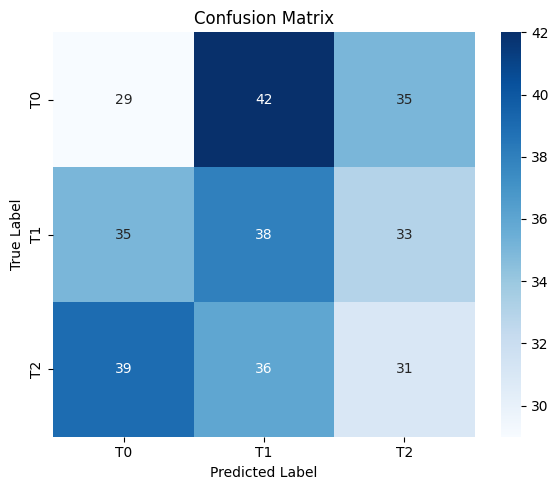

In [57]:
# Switch to eval mode
model.eval()

# Run predictions on validation set
all_preds = []
all_targets = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(labels.numpy())

# Classification report
print("\nClassification Report:")
print(classification_report(all_targets, all_preds, target_names=['Rest (T0)', 'Left Fist (T1)', 'Right Fist (T2)']))

# Confusion matrix
cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['T0', 'T1', 'T2'], yticklabels=['T0', 'T1', 'T2'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

#### 7.2 CNN Model Definition (1D Conv) + Transformer (Hybrid)

In [79]:
# The original labels include Rest (T0), Left (T1), and Right (T2), we must filter out T0 (Rest).
# Then, we relabel: Left = 0, Right = 1.

mask = y_balanced != 0  # Keep only T1 and T2
X_movement = X_balanced[mask]
y_movement = y_balanced[mask]

# Relabel: Left movement -> 0, Right movement -> 1
y_movement = (y_movement == 2).astype(int)

print(f"X shape after filtering: {X_movement.shape}")
print(f"y distribution: {np.bincount(y_movement)}")

X shape after filtering: (224, 64, 321)
y distribution: [112 112]


In [80]:
# Normalize EEG trials independently (Z-score per trial)

# Each trial is normalized individually across time for each channel.
# This ensures each trial has zero mean and unit variance, preventing amplitude bias.

X_movement = (X_movement - X_movement.mean(axis=2, keepdims=True)) / X_movement.std(axis=2, keepdims=True)


Splitting into Train/Validation Sets and Tensor Conversion


In [81]:
# Labels must be float type and reshaped to (N, 1) because BCEWithLogitsLoss expects float tensors.

X_train, X_val, y_train, y_val = train_test_split(
    X_movement, y_movement, test_size=0.2, stratify=y_movement, random_state=42
)

# Convert into PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1)
y_val = torch.tensor(y_val, dtype=torch.float32).unsqueeze(-1)

# Create DataLoaders
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)


Now let's define CNN + Transformer + MLP Model

In [82]:
# The model has three stages:
# (1) A CNN extracts spatial features from EEG channels.
# (2) A Transformer encoder models temporal dependencies across timepoints.
# (3) An MLP performs binary classification.

class EEG_CNN_Transformer_MLP(nn.Module):
    def __init__(self, input_channels=64, time_steps=321):
        super(EEG_CNN_Transformer_MLP, self).__init__()

        # Convolutional feature extractor
        self.conv1 = nn.Conv1d(input_channels, 128, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm1d(128)

        # Transformer encoder for temporal dependencies
        encoder_layer = nn.TransformerEncoderLayer(d_model=128, nhead=8, dim_feedforward=256, dropout=0.2)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=2)

        # MLP for final prediction
        self.fc1 = nn.Linear(128, 64)
        self.fc2 = nn.Linear(64, 1)  # Single neuron for binary output

    def forward(self, x):
        # Input: (batch_size, channels, timepoints)
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)

        # Prepare for transformer: (timepoints, batch_size, features)
        x = x.permute(2, 0, 1)
        x = self.transformer_encoder(x)
        x = x.permute(1, 2, 0)

        # Global average pooling over time
        x = x.mean(dim=2)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x


Training the Model

In [83]:
# Initialize model and move to device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = EEG_CNN_Transformer_MLP().to(device)

# Binary classification loss and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training configuration
epochs = 50
best_val_loss = float('inf')
patience = 10                    # Max epochs to wait for improvement
epochs_no_improve = 0            # Counter for early stopping
best_model = None

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)

    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

    # Check for improvement
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model = model.state_dict()
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f"  ↪ No improvement for {epochs_no_improve} epoch(s)")

        # Early stopping condition
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break

# Load the best model before evaluation
model.load_state_dict(best_model)


C:\Users\angom\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1/50 - Train Loss: 0.7011, Val Loss: 0.7026
Epoch 2/50 - Train Loss: 0.6911, Val Loss: 0.6925
Epoch 3/50 - Train Loss: 0.6824, Val Loss: 0.6976
  ↪ No improvement for 1 epoch(s)
Epoch 4/50 - Train Loss: 0.6703, Val Loss: 0.7107
  ↪ No improvement for 2 epoch(s)
Epoch 5/50 - Train Loss: 0.6150, Val Loss: 0.7477
  ↪ No improvement for 3 epoch(s)
Epoch 6/50 - Train Loss: 0.6115, Val Loss: 0.7246
  ↪ No improvement for 4 epoch(s)
Epoch 7/50 - Train Loss: 0.4951, Val Loss: 0.6712
Epoch 8/50 - Train Loss: 0.4340, Val Loss: 0.6786
  ↪ No improvement for 1 epoch(s)
Epoch 9/50 - Train Loss: 0.3519, Val Loss: 0.8226
  ↪ No improvement for 2 epoch(s)
Epoch 10/50 - Train Loss: 0.3091, Val Loss: 0.8579
  ↪ No improvement for 3 epoch(s)
Epoch 11/50 - Train Loss: 0.3919, Val Loss: 0.7958
  ↪ No improvement for 4 epoch(s)
Epoch 12/50 - Train Loss: 0.3006, Val Loss: 0.7593
  ↪ No improvement for 5 epoch(s)
Epoch 13/50 - Train Loss: 0.2517, Val Loss: 0.7993
  ↪ No improvement for 6 epoch(s)
Epoch 

<All keys matched successfully>

Evaluating the Final Model

In [84]:
# After training, we evaluate using the best model found during validation.
# We use sigmoid activation to interpret logits as probabilities,
# and then threshold at 0.5 to predict class labels.

# Load best model
model.load_state_dict(best_model)
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()
        all_preds.extend(preds.flatten())
        all_targets.extend(labels.cpu().numpy().flatten())

# Classification report
print(classification_report(all_targets, all_preds, target_names=['Left Fist', 'Right Fist']))


              precision    recall  f1-score   support

   Left Fist       0.75      0.78      0.77        23
  Right Fist       0.76      0.73      0.74        22

    accuracy                           0.76        45
   macro avg       0.76      0.75      0.76        45
weighted avg       0.76      0.76      0.76        45



76% is a major improvement. We can still push a little bit more.

#### 7.3 CNN Two Conv1D Layers

Adds a second Conv1D layer for deeper spatial feature learning

Includes BatchNorm and ReLU between layers

In [91]:
class EEG_CNN_Deep(nn.Module):
    def __init__(self, input_shape, hidden_dim=128, output_dim=3, dropout_rate=0.5):
        super(EEG_CNN_Deep, self).__init__()
        n_channels = input_shape[1]
        n_timepoints = input_shape[2]

        self.conv1 = nn.Conv1d(n_channels, 64, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(64, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(64)

        self.global_avg_pool = nn.AdaptiveAvgPool1d(1)

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        # Input: (batch, channels, timepoints)
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)

        x = self.global_avg_pool(x)  # shape: (batch, 64, 1)
        return self.fc(x)

In [92]:
input_shape = (None, X_train.shape[1], X_train.shape[2])
model = EEG_CNN_Deep(input_shape=input_shape, output_dim=3).to(device)  # or output_dim=2 for binary

In [93]:
print(X_train.shape)

torch.Size([179, 64, 321])


In [96]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Ensure labels are 1D LongTensors
y_train = torch.tensor(y_train, dtype=torch.long).squeeze()
y_val = torch.tensor(y_val, dtype=torch.long).squeeze()

# Rebuild DataLoaders with corrected label shape
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Early stopping settings
patience = 10
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_state = None

# Training loop
num_epochs = 100
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

    # Early stopping check
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = model.state_dict()
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("Early stopping triggered.")
            break

# Load best model
model.load_state_dict(best_model_state)


Using device: cpu
Epoch 1/100 - Train Loss: 0.1154, Val Loss: 1.2077


C:\Users\angom\AppData\Local\Temp\ipykernel_14056\1351543651.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_train, dtype=torch.long).squeeze()
C:\Users\angom\AppData\Local\Temp\ipykernel_14056\1351543651.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_val = torch.tensor(y_val, dtype=torch.long).squeeze()


Epoch 2/100 - Train Loss: 0.0534, Val Loss: 1.0493
Epoch 3/100 - Train Loss: 0.0814, Val Loss: 1.5613
Epoch 4/100 - Train Loss: 0.0951, Val Loss: 0.6734
Epoch 5/100 - Train Loss: 0.0843, Val Loss: 0.8424
Epoch 6/100 - Train Loss: 0.0452, Val Loss: 0.6975
Epoch 7/100 - Train Loss: 0.0365, Val Loss: 0.7595
Epoch 8/100 - Train Loss: 0.0288, Val Loss: 0.8395
Epoch 9/100 - Train Loss: 0.0300, Val Loss: 0.9624
Epoch 10/100 - Train Loss: 0.0317, Val Loss: 0.7636
Epoch 11/100 - Train Loss: 0.0170, Val Loss: 0.6636
Epoch 12/100 - Train Loss: 0.0184, Val Loss: 0.6761
Epoch 13/100 - Train Loss: 0.0085, Val Loss: 0.7775
Epoch 14/100 - Train Loss: 0.0113, Val Loss: 0.7870
Epoch 15/100 - Train Loss: 0.0209, Val Loss: 0.7329
Epoch 16/100 - Train Loss: 0.0083, Val Loss: 0.7476
Epoch 17/100 - Train Loss: 0.0111, Val Loss: 0.7638
Epoch 18/100 - Train Loss: 0.0120, Val Loss: 0.7973
Epoch 19/100 - Train Loss: 0.0095, Val Loss: 0.8665
Epoch 20/100 - Train Loss: 0.0053, Val Loss: 0.9288
Epoch 21/100 - Train

<All keys matched successfully>

Classification Report:
              precision    recall  f1-score   support

   Left Fist       0.76      0.83      0.79        23
  Right Fist       0.80      0.73      0.76        22

    accuracy                           0.78        45
   macro avg       0.78      0.78      0.78        45
weighted avg       0.78      0.78      0.78        45



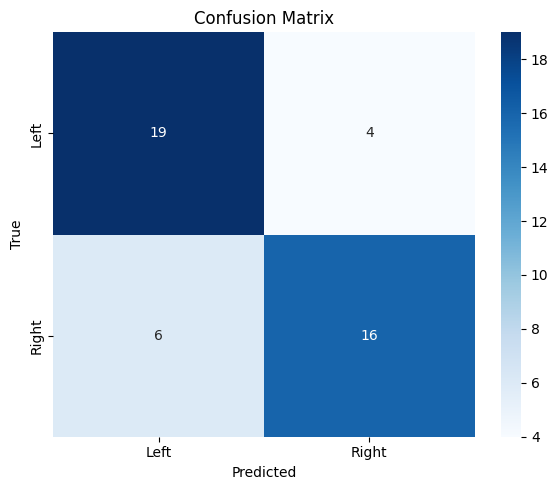

In [97]:
# Ensure model is in evaluation mode
model.eval()

# Collect predictions and true labels
all_preds = []
all_targets = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(labels.cpu().numpy())

# Adjust target names for binary case
print("Classification Report:")
print(classification_report(all_targets, all_preds, target_names=["Left Fist", "Right Fist"]))

# Plot confusion matrix
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Left", "Right"], yticklabels=["Left", "Right"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


This is the best result obtained so far.

#### (ROC + PR Curve)

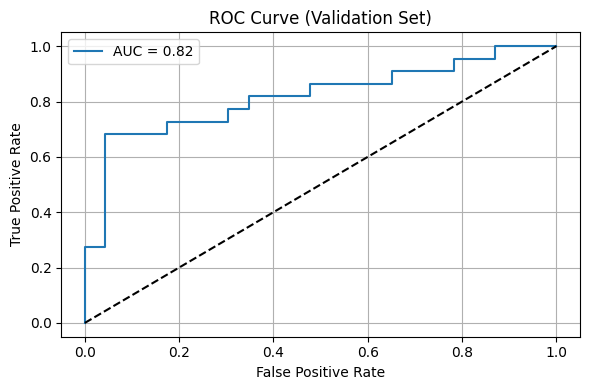

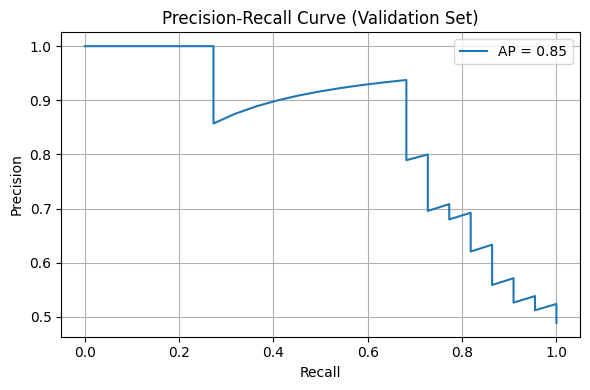

In [98]:
# Collect probabilities and true labels
model.eval()
probs = []
targets = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        probs_batch = torch.softmax(outputs, dim=1)[:, 1]  # class 1: Right Fist
        probs.extend(probs_batch.cpu().numpy())
        targets.extend(labels.cpu().numpy())

# ROC Curve
fpr, tpr, _ = roc_curve(targets, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Validation Set)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(targets, probs)
ap = average_precision_score(targets, probs)

plt.figure(figsize=(6, 4))
plt.plot(recall, precision, label=f'AP = {ap:.2f}')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Validation Set)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
